# Data directory setup

In [38]:
from pathlib import Path

KAGGLE_DATA_DIR = Path("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3")
LOCAL_DATA_DIR = Path("./data")

DATA_DIR = KAGGLE_DATA_DIR if KAGGLE_DATA_DIR.exists() else LOCAL_DATA_DIR

print(f"Using data directory: {DATA_DIR}")

Using data directory: data


# Load CSVs

In [39]:
import pandas as pd

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

train_df.head()

Train shape: (7000, 6)
Test shape:  (1700, 5)


,id,phrase,feature_1,feature_2,feature_3,sentiment
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0
1,1,You have to see it .,6.0,1.0,NaN,2
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2


# Numerical and text columns

In [40]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.2+ KB


In [41]:
numerical_cols = train_df.select_dtypes(include='number').columns.tolist()
text_cols = train_df.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Text columns:      {text_cols}")

Numerical columns: ['id', 'feature_1', 'feature_2', 'feature_3', 'sentiment']
Text columns:      ['phrase']


# Descriptive statistics

In [42]:
train_df.describe()

,id,feature_1,feature_2,feature_3,sentiment
count,7000.000000,6088.000000,5896.000000,5938.000000,7000.000000
mean,3499.500000,19.025624,1.996608,3.334119,1.041143
std,2020.870275,9.303562,1.634858,2.321154,0.898010
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1749.750000,12.000000,1.000000,2.000000,0.000000
50%,3499.500000,18.000000,1.000000,3.000000,1.000000
75%,5249.250000,25.000000,3.000000,4.000000,2.000000
max,6999.000000,52.000000,19.000000,19.000000,2.000000


# Missing values

In [43]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0')

print(missing_df if not missing_df.empty else "No missing values found.")

           missing_count  missing_pct
feature_1            912    13.028571
feature_2           1104    15.771429
feature_3           1062    15.171429


# Duplicates

In [44]:
duplicate_count = train_df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
  train_df = train_df.drop_duplicates()
  print(f"Duplicates dropped. New shape: {train_df.shape}")
else:
  print("No duplicates to drop.")

Duplicate rows found: 0
No duplicates to drop.


# Outliers via IQR

In [45]:
outlier_summary = []

for col in numerical_cols:
  Q1 = train_df[col].quantile(0.25)
  Q3 = train_df[col].quantile(0.75)
  IQR = Q3 - Q1
  outliers = train_df[(train_df[col] < Q1 - 1.5 * IQR) | (train_df[col] > Q3 + 1.5 * IQR)]
  count = len(outliers)
  pct = (count / len(train_df)) * 100
  outlier_summary.append({'column': col, 'outlier_count': count, 'outlier_pct': round(pct, 2)})

outlier_df = pd.DataFrame(outlier_summary).query('outlier_count > 0')

print(outlier_df if not outlier_df.empty else "No outliers found.")

      column  outlier_count  outlier_pct
1  feature_1             45         0.64
2  feature_2            150         2.14
3  feature_3            331         4.73


# Histograms of numerical columns

In [46]:
import matplotlib.pyplot as plt

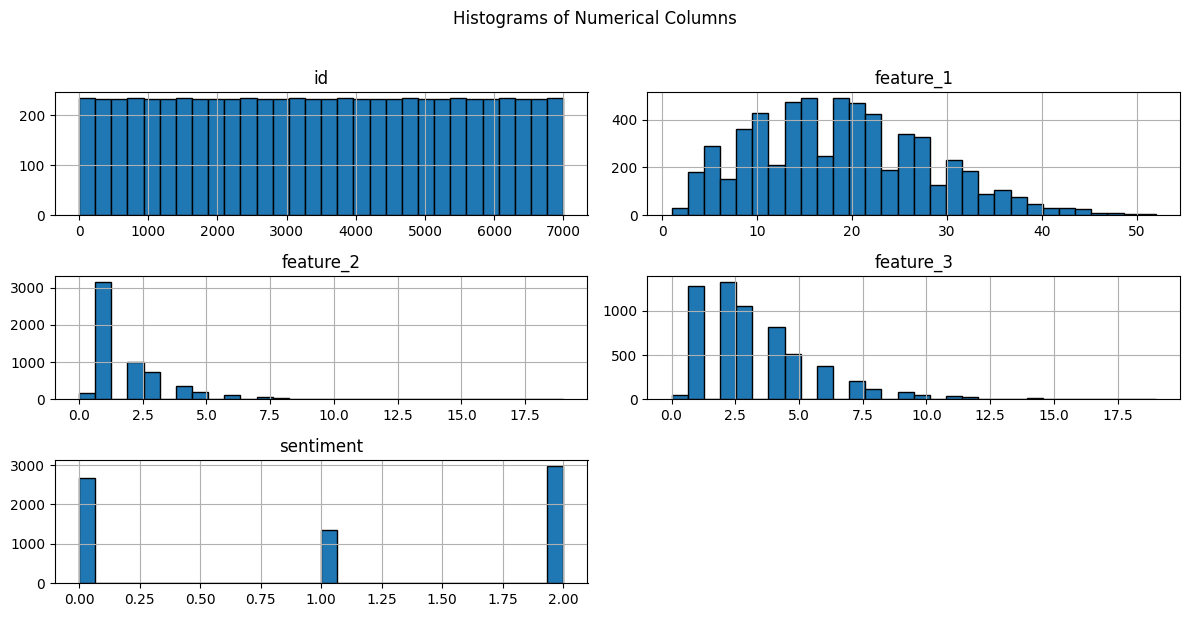

In [47]:
_ = train_df[numerical_cols].hist(figsize=(12, 6), bins=30, edgecolor='black')
_ = plt.suptitle("Histograms of Numerical Columns", y=1.02)
_ = plt.tight_layout()

# Target class distribution

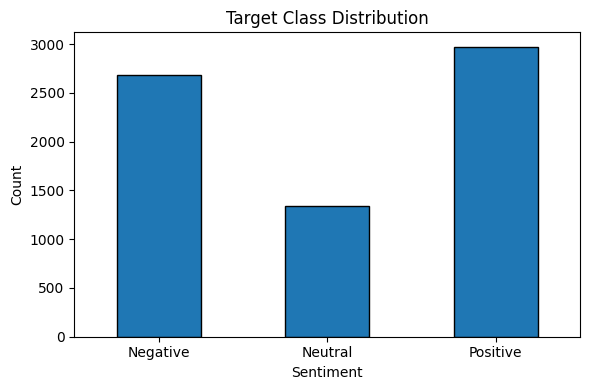

In [48]:
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

_ = train_df['sentiment'].value_counts().sort_index().rename(index=label_map).plot(
    kind='bar', edgecolor='black', figsize=(6, 4)
)
_ = plt.title("Target Class Distribution")
_ = plt.xlabel("Sentiment")
_ = plt.ylabel("Count")
_ = plt.xticks(rotation=0)
_ = plt.tight_layout()

# Scatter plots of features colored by sentiment

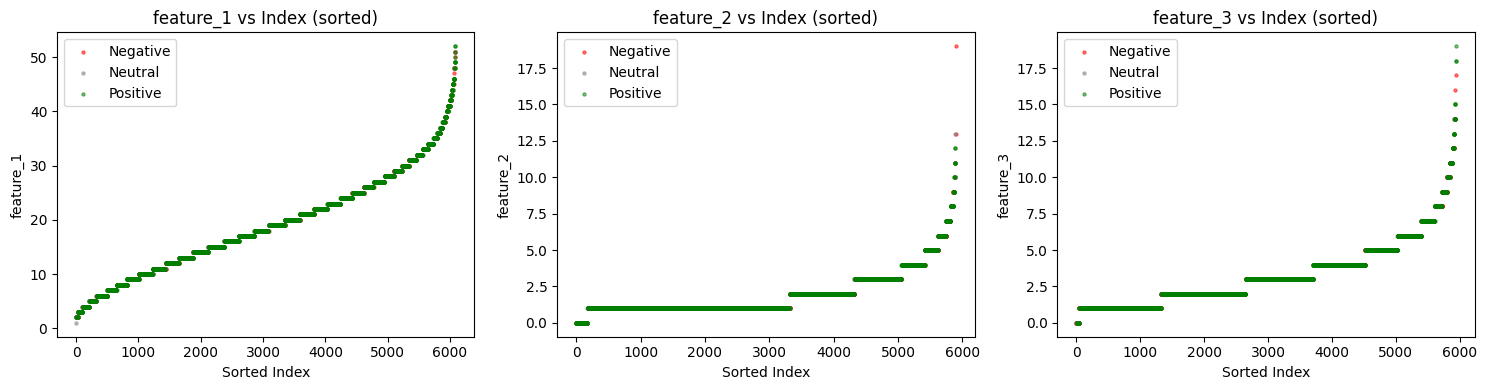

In [49]:
features = ['feature_1', 'feature_2', 'feature_3']
colors = {0: 'red', 1: 'gray', 2: 'green'}
labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, features):
  sorted_df = train_df[['sentiment', feature]].sort_values(by=feature).reset_index(drop=True)
  for sentiment, group in sorted_df.groupby('sentiment'):
    _ = ax.scatter(group.index, group[feature], c=colors[sentiment],
                   label=labels[sentiment], alpha=0.5, s=5)
  _ = ax.set_title(f"{feature} vs Index (sorted)")
  _ = ax.set_xlabel("Sorted Index")
  _ = ax.set_ylabel(feature)
  _ = ax.legend()

_ = plt.tight_layout()

# Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


# 1. Define feature engineering logic
def add_engineered_features(df):
  df = df.copy()
  df['phrase'] = df['phrase'].fillna('')

  # TextBlob features
  polarities, subjectivities = [], []
  for text in df['phrase']:
    blob = TextBlob(str(text))
    polarities.append(blob.sentiment.polarity)
    subjectivities.append(blob.sentiment.subjectivity)

  df['polarity'] = polarities
  df['subjectivity'] = subjectivities

  # Hand-crafted text features
  df['char_len'] = df['phrase'].str.len()
  df['word_count'] = df['phrase'].str.split().str.len()
  df['avg_word_len'] = df['phrase'].apply(
      lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
  )
  df['exclaim_count'] = df['phrase'].str.count('!')
  df['question_count'] = df['phrase'].str.count(r'\?')
  df['upper_ratio'] = df['phrase'].apply(
      lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
  )

  # Specific sentiment dictionaries
  neg_words = ['not', 'no', 'never', 'bad', 'worst', 'boring']
  pos_words = ['great', 'good', 'excellent', 'amazing', 'best']

  df['neg_word_count'] = df['phrase'].apply(
      lambda x: sum(x.lower().count(w) for w in neg_words)
  )
  df['pos_word_count'] = df['phrase'].apply(
      lambda x: sum(x.lower().count(w) for w in pos_words)
  )
  return df


# 2. Extract base features and target
X = train_df.drop(columns=['id', 'sentiment'])
y = train_df['sentiment']
X_test = test_df.drop(columns=['id'])

# 3. Apply Feature Engineering directly to X BEFORE train/val split
X = add_engineered_features(X)
X_test = add_engineered_features(X_test)

# 4. Perform the Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

In [ ]:
# 5. Define Feature Lists
ORIGINAL_NUM_FEATURES = ['feature_1', 'feature_2', 'feature_3']
ENGINEERED_FEATURES = [
    'polarity', 'subjectivity', 'char_len', 'word_count',
    'avg_word_len', 'exclaim_count', 'question_count',
    'upper_ratio', 'neg_word_count', 'pos_word_count'
]
ALL_NUMERICAL_FEATURES = ORIGINAL_NUM_FEATURES + ENGINEERED_FEATURES
TEXT_FEATURE = 'phrase'

# 6. Shared Numerical Pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ---------------------------------------------------------
# 1: Validation Preprocessor (Used for model testing)
# ---------------------------------------------------------
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        min_df=2,              
        max_df=0.95,
        ngram_range=(1, 2),
        sublinear_tf=True
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, ALL_NUMERICAL_FEATURES),
    ('text', text_pipeline, TEXT_FEATURE)
])

# Fit/Transform Validation Set
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)


# ---------------------------------------------------------
# 2: Full Preprocessor (Used for final submission)
# ---------------------------------------------------------
# Based on your previous notebook configuration for the full data
text_pipeline_full = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,    # Increased vocabulary size for full data
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 3),    # Includes trigrams for the final model
        sublinear_tf=True
    ))
])

preprocessor_full = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, ALL_NUMERICAL_FEATURES),
    ('text', text_pipeline_full, TEXT_FEATURE)
])

# Fit/Transform Full Data Set
X_full_processed = preprocessor_full.fit_transform(X)
X_test_processed_full = preprocessor_full.transform(X_test)

In [90]:
# Print shapes of all processed arrays to confirm preprocessing
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_val_processed shape:   {X_val_processed.shape}")
print("-" * 40)
print(f"X_full_processed shape:  {X_full_processed.shape}")
print(f"X_test_processed_full shape: {X_test_processed_full.shape}")

X_train_processed shape: (6300, 10013)
X_val_processed shape:   (700, 10013)
----------------------------------------
X_full_processed shape:  (7000, 20013)
X_test_processed_full shape: (1700, 20013)


# Model building and evaluation

In [54]:
from sklearn.metrics import accuracy_score

results = {}


def evaluate(name, model):
  model.fit(X_train_processed, y_train)
  val_preds = model.predict(X_val_processed)
  acc = accuracy_score(y_val, val_preds)
  results[name] = {'model': model, 'val_accuracy': round(acc, 4)}
  print(f"{name:<35} Val Accuracy: {acc:.4f}")

In [57]:
import warnings
warnings.filterwarnings('ignore')

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier

models = {
    'Logistic Regression': LogisticRegression(
        C=5,              # inverse regularization strength, higher = less regularized
        max_iter=1000,    # max iterations for solver to converge
        solver='saga',    # works well for large sparse datasets
        n_jobs=-1,        # use all cores
        class_weight='balanced',  # for unbalanced target
    ),
    'Linear SVC': LinearSVC(
        C=1.0,            # regularization strength
        max_iter=2000,    # max iterations for convergence
        class_weight='balanced',  # for unbalanced target
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500,  # number of trees
        max_depth=30,     # max depth of each tree
        min_samples_leaf=2,  # min samples required at a leaf node
        n_jobs=-1,        # use all cores
        random_state=42,
        class_weight='balanced',  # for unbalanced target
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=500,  # number of trees
        max_depth=30,     # max depth of each tree
        min_samples_leaf=2,  # min samples required at a leaf node
        n_jobs=-1,        # use all cores
        random_state=42,
        class_weight='balanced',  # for unbalanced target
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,  # number of boosting stages
        max_depth=5,      # max depth of each tree
        learning_rate=0.1,  # shrinks contribution of each tree
        random_state=42,
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=15,   # number of neighbors to consider
        metric='cosine',  # cosine similarity works well for TF-IDF vectors
        n_jobs=-1,        # use all cores
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500,  # number of boosting rounds
        max_depth=10,     # max depth of each tree
        learning_rate=0.05,  # shrinks contribution of each tree
        num_leaves=63,    # max number of leaves per tree
        n_jobs=-1,        # use all cores
        random_state=42,
        verbosity=-1,     # suppress all warnings and logs
        class_weight='balanced',  # for unbalanced target
    ),
}

print(f"{'Model':<35} {'Val Accuracy'}")
print("-" * 50)

for name, model in models.items():
  evaluate(name, model)

Model                               Val Accuracy
--------------------------------------------------
Logistic Regression                 Val Accuracy: 0.6329
Linear SVC                          Val Accuracy: 0.6229
Random Forest                       Val Accuracy: 0.5886
Extra Trees                         Val Accuracy: 0.5814
Gradient Boosting                   Val Accuracy: 0.6086
K-Nearest Neighbors                 Val Accuracy: 0.5271
LightGBM                            Val Accuracy: 0.5857


## Hyperparameter tuning

In [59]:
from sklearn.model_selection import GridSearchCV

tuning_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1),
        'params': {
            'C': [1, 5, 10],
        }
    },
    'Linear SVC': {
        'model': LinearSVC(max_iter=2000),
        'params': {
            'C': [0.5, 1.0, 2.0],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
        }
    },
}

tuned_results = {}

for name, config in tuning_configs.items():
  print(f"Tuning {name}...")
  gs = GridSearchCV(
      config['model'],
      config['params'],
      cv=3,
      scoring='accuracy',
      n_jobs=-1,
  )
  gs.fit(X_train_processed, y_train)
  val_acc = accuracy_score(y_val, gs.predict(X_val_processed))
  tuned_results[name] = {
      'best_params': gs.best_params_,
      'best_model': gs.best_estimator_,
      'val_accuracy': round(val_acc, 4),
  }
  print(f"  Best Params:  {gs.best_params_}")
  print(f"  Val Accuracy: {val_acc:.4f}\n")

Tuning Logistic Regression...


,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [1, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


  Best Params:  {'C': 1}
  Val Accuracy: 0.6500

Tuning Linear SVC...


,estimator,LinearSVC(max_iter=2000)
,param_grid,"{'C': [0.5, 1.0, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


  Best Params:  {'C': 0.5}
  Val Accuracy: 0.6457

Tuning Gradient Boosting...


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


  Best Params:  {'learning_rate': 0.1, 'n_estimators': 200}
  Val Accuracy: 0.5671



## Model comparison

In [60]:
print(f"{'Model':<35} {'Val Accuracy':<15} {'Note'}")
print("-" * 65)

for name, info in results.items():
  print(f"{name:<35} {info['val_accuracy']:<15}")

print()

for name, info in tuned_results.items():
  print(f"{name + ' (Tuned)':<35} {info['val_accuracy']:<15} {str(info['best_params'])}")

Model                               Val Accuracy    Note
-----------------------------------------------------------------
Logistic Regression                 0.6386         
Linear SVC                          0.6229         
Random Forest                       0.5714         
Extra Trees                         0.5543         
Gradient Boosting                   0.5757         
K-Nearest Neighbors                 0.4243         
LightGBM                            0.5586         

Logistic Regression (Tuned)         0.65            {'C': 1}
Linear SVC (Tuned)                  0.6457          {'C': 0.5}
Gradient Boosting (Tuned)           0.5671          {'learning_rate': 0.1, 'n_estimators': 200}


## Retrain on full data and generate submission

In [93]:
best_model = LinearSVC(C=0.5, max_iter=2000)
best_model.fit(X_full_processed, y)

test_preds = best_model.predict(X_test_processed_full)

submission = pd.DataFrame({
    'id': test_df['id'],
    'sentiment': test_preds
})

submission.to_csv('./submission.csv', index=False)
print(submission.shape)
submission.head()

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


(1700, 2)


,id,sentiment
0,0,0
1,1,2
2,2,2
3,3,2
4,4,0
